# Chapter 17: State and Consequence

The request left the controller. Its acknowledgement did not return. That observation supports two different stories: the tool may have done nothing, or it may have completed the effect and lost the reply. Sending the request again can resolve the first story and damage the second. A retry counter does not tell the controller which world it occupies.

This experiment gives you a local event ledger in which the actual effect and the received acknowledgement are separate fields. The ledger is constructed so the distinction can be inspected directly. In a real interface, the effect field would require an audit log, a durable receipt, or a verification query; it is not something the agent can infer from silence.

The default trace contains one effect without an acknowledgement and then a repeated request. First predict the cumulative effect count. Next ask what changes if the service stores an idempotency key and binds that key to the exact payload. Finally compare the cost of a verification query with the expected cost of a blind retry. These are three separate questions: what happened, what was confirmed, and what should happen next.

**Outcome:** Separate effects from acknowledgements and price a next recovery step.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- Event traces and conditional probability

## The question and its mathematics

Let E_t count durable effects after event t, and let C_t indicate whether at least one effect has been confirmed. A request whose effect flag is true increments E_t unless a valid idempotency contract recognizes the same key and payload. Its acknowledgement changes C_t; losing that acknowledgement does not undo the effect. A verification event can confirm an effect already present in the ledger.

An idempotency key is useful only if the receiving service records and checks it. Here the key maps to a payload identifier. Repeating the same pair suppresses an additional effect when idempotence is enabled. Reusing a stored key for a different payload raises an error because the requested contract is ambiguous. Counting repeated attempts without this mapping would not establish idempotence.

For one unresolved request, let p denote the conditional probability that it already took effect. Let c_r be the retry cost, d the harm of a duplicate, and c_v the cost of perfect verification. A nonidempotent retry has expected next-step cost c_r+pd. With the declared idempotency contract, duplicate harm vanishes and this comparison becomes c_r against c_v. This small calculation omits the benefit and cost of any later recovery steps.

The distinction between conditional belief and recorded truth matters. The trace says what happened in this constructed run; p represents what the controller believes before resolving an uncertain request. Neither quantity can replace the other in a deployed report.

## A calculation you can run

Read the trace in order. A request includes a key, payload identifier, actual effect flag, and received acknowledgement flag. A verification includes whether the existing effect was observed. The computation maintains the effect count, key ledger, confirmation status, and unresolved-effect status, then emits a row after each event. Exact boolean checks prevent strings such as "false" from being treated as truthy evidence.

Two charts show cumulative effects and confirmation over event index. The first can rise while the second remains zero. That separation is the reason this notebook exists. A confirmation of an absent effect is rejected rather than silently accepted. The local trace is deliberately stronger than ordinary client logs because it has the ground truth needed to teach and test the inference boundary.

The cost comparison uses separate declared inputs. It does not estimate the unresolved-effect probability from the trace, nor does it assume retries are independent. The changed case enables the key/payload contract while preserving the same event sequence. The transfer case replaces the retry with verification, so you can inspect how uncertainty is resolved without increasing the effect count.

Once the logical effect is confirmed and no uncertainty remains, the recommended next step is stop. The verification and retry prices remain visible for inspecting the unresolved decision point; they do not justify another request after completion. Different payloads are rejected because this ledger counts duplicates of one intended logical operation.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 17
inputs = {'idempotent': False,
 'events': [{'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': False},
            {'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': True}],
 'verify_cost': 1,
 'retry_cost': 0.2,
 'effect_probability': 0.8,
 'duplicate_cost': 10}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: constructed teaching example

Calculated quantities:
{
  "effects": 2,
  "duplicate_effects": 1,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 1.0,
  "retry_expected_cost": 8.2,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


The first default request produces one effect and no acknowledgement. The second produces another effect and receives an acknowledgement. The terminal ledger therefore has two effects, one duplicate relative to the intended single operation, and confirmation of at least one effect. Confirmation does not prove uniqueness.

Blind retry costs 0.2+0.8(10)=8.2 in the declared next-step comparison. Verification costs 1, so at the unresolved decision point verification would be preferred. In this finished trace the second acknowledgement has already confirmed an effect, so the reported preferred_next_step is stop; the prices apply to the moment before that confirmation. Enabling idempotence suppresses the repeated same-key effect: the count stays at one and duplicate count falls to zero. The retry comparison then costs 0.2, below verification. This reversal follows from a receiving-service contract, not from the controller deciding that a retry is probably safe. Keep the key, payload, and service behavior in the evidence record.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


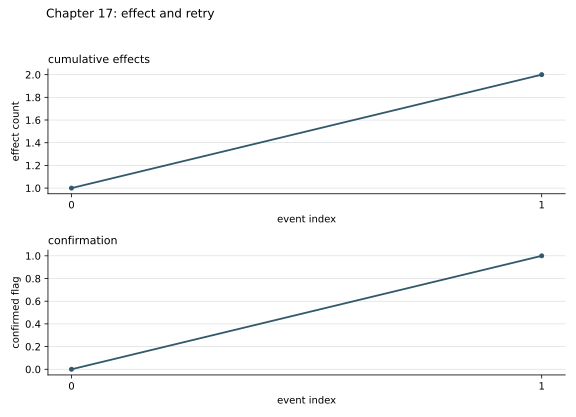

In [3]:
display(SVG(figure_svg(report)))

**Figure 17.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The most dangerous shortcut is to equate an absent acknowledgement with an absent effect. That rule encourages the controller to replay actions whose consequences may already be durable. The converse shortcut also fails: receiving an acknowledgement does not establish that only one effect occurred. The default trace ends with confirmation and a duplicate.

A second failure concerns idempotency scope. A key that is checked only in client memory cannot protect against service restarts, multiple clients, or an independently repeated operation. This implementation assumes the receiver's key ledger is the effect boundary. If a real service has a retention window, payload normalization rule, or transaction boundary, those conditions must be added before adopting the simplified cost comparison.

Verification has its own limitations. The comparison assumes a perfect query, while real observations can be stale or ambiguous. A false negative could provoke another retry; a false positive could terminate a workflow that never completed. Do not treat the returned recommendation as a complete recovery controller. It prices one next step under a declared conditional belief and a specific duplicate-harm contract.

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "effects": 1,
  "duplicate_effects": 0,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 1.0,
  "retry_expected_cost": 0.2,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


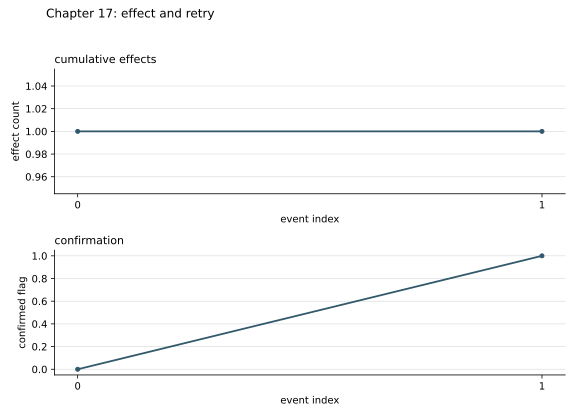

In [4]:
changed_inputs = {'idempotent': True,
 'events': [{'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': False},
            {'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': True}],
 'verify_cost': 1,
 'retry_cost': 0.2,
 'effect_probability': 0.8,
 'duplicate_cost': 10}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 17.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer trace uses a request with a lost acknowledgement followed by an explicit verification. Its effect count stays at one, and confirmation becomes true at the second event. The verification cost is 0.5; blind retry would cost 0.1+0.6(4)=2.5, so at an unresolved decision point the declared comparison again favors verification. Because this trace is already confirmed, the reported preferred_next_step is stop.

For reader data, preserve event order and give each effect-bearing request its durable operation identifier. If you have only client logs, mark actual effect as unknown in your measurement design instead of inventing a boolean and passing it to this deterministic replay. Obtain server evidence or construct separate possible traces. Compare those traces to identify which next observation would distinguish them. The method is useful precisely because it refuses to turn transport uncertainty into a fabricated state fact.

In [5]:
transfer_inputs = {'idempotent': False,
 'events': [{'kind': 'request',
             'key': 'send-2',
             'payload': 'packet-B',
             'effect': True,
             'ack': False},
            {'kind': 'verify', 'observed_effect': True}],
 'verify_cost': 0.5,
 'retry_cost': 0.1,
 'effect_probability': 0.6,
 'duplicate_cost': 4}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: constructed transfer example

Calculated quantities:
{
  "effects": 1,
  "duplicate_effects": 0,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 0.5,
  "retry_expected_cost": 2.5,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **idempotent:** Exact boolean. True declares server-side key/payload deduplication.
- **events:** Ordered event list: request has kind,key,payload,effect:boolean,ack:boolean; verify has observed_effect:boolean. All requests must concern one logical payload; distinct operations require separate traces.
- **verify_cost:** Nonnegative one-step cost of perfect verification.
- **retry_cost:** Nonnegative one-step request cost.
- **effect_probability:** Probability [0,1] that the unresolved original request already took effect.
- **duplicate_cost:** Nonnegative extra harm from a duplicate effect.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch17.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "effects": 1,
  "duplicate_effects": 0,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 0.5,
  "retry_expected_cost": 2.5,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. How many effects occur in the default trace?

2. What duplicate-harm value makes verification and retry tie?

3. What happens when a stored idempotency key is reused with a different payload?

Answers: [separate solutions](../solutions/ch17.md). Try the calculation before opening them.

## Summary

An action, an effect, and an acknowledgement are different events. The ledger counts effects separately from confirmation and shows how a blind retry can duplicate a completed operation. A valid idempotency contract suppresses repeated same-key, same-payload effects; a key conflict is rejected. The next-step cost comparison uses a declared unresolved-effect probability and duplicate harm. It does not guarantee recovery or infer remote state. For practical use, preserve durable identifiers, verify ambiguous consequences, and record the service-side conditions that make replay safe. A confirmed effect can still be duplicated, unauthorized, or incomplete at the workflow level.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-17-effect-and-retry`](../skills/maa-17-effect-and-retry/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 17.1

![Equation 17.1](../assets/math/521f3b91c8104d451a8b.svg)

Equation (17.1) requires repeated application to preserve the same intended effect as one application.

Compare the resulting requested-effect coordinates after one application and after two, keeping the request semantics fixed.

LaTeX source, preserved for inspection:

```latex
\operatorname{eff}_{I}\!\big(\operatorname{eff}(T,\operatorname{eff}(T,x))\big) \;=\; \operatorname{eff}_{I}\!\big(\operatorname{eff}(T,x)\big)
\qquad\text{for every reachable } x .
\tag{17.1}
```

### Equation 17.2

![Equation 17.2](../assets/math/9fd25b8ba498db8f883f.svg)

Equation (17.2) converts a missing response into a probability that the action already happened.

Weigh how likely silence is when the effect landed against how likely silence is when it did not.

LaTeX source, preserved for inspection:

```latex
\mathbf{b}'(\text{applied}) \;=\;
\frac{\operatorname{Obs}(\varnothing \mid \text{applied})\;\Pr(\text{applied})}
{\begin{gathered}
\operatorname{Obs}(\varnothing \mid \text{applied})\,\Pr(\text{applied}) \\
{}+\; \operatorname{Obs}(\varnothing \mid \text{not applied})\,\Pr(\text{not applied})
\end{gathered}}.
\tag{17.2}
```

### Equation 17.3

![Equation 17.3](../assets/math/06754fe168697c58639b.svg)

Equation (17.3) says whether sending the request again is worth it.

Weigh the chance the action is still needed, times the cost of skipping it, against the chance it already happened, times the cost of doing it twice.

LaTeX source, preserved for inspection:

```latex
\operatorname{EU}(\text{retry}) - \operatorname{EU}(\text{decline}) \;=\; (1-\beta)\,c_{\text{miss}} \;-\; \beta\,c_{\text{dup}} .
\tag{17.3}
```

### Equation 17.4

![Equation 17.4](../assets/math/574a1266b01fa51afc80.svg)

Equation (17.4) identifies repeat attempts whose duplicate-effect risk is resolved and whose current execution conditions have been checked.

Check authority and preconditions, then require applicable idempotent semantics, proof of terminal non-application, or verified restoration after completed recovery.

LaTeX source, preserved for inspection:

```latex
\operatorname{Rep}(x) \;=\; \Big\{\, T \;:\; \operatorname{Ready}(T,x)\;\land\;\big[\text{(17.1) holds for this request}\;\lor\;\operatorname{Absent}(T,x)\;\lor\;\operatorname{Restored}(T,x)\big] \,\Big\}.
\tag{17.4}
```